In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from sklearn.mixture import GaussianMixture

In [2]:
data=np.load("formationchannels.npy")

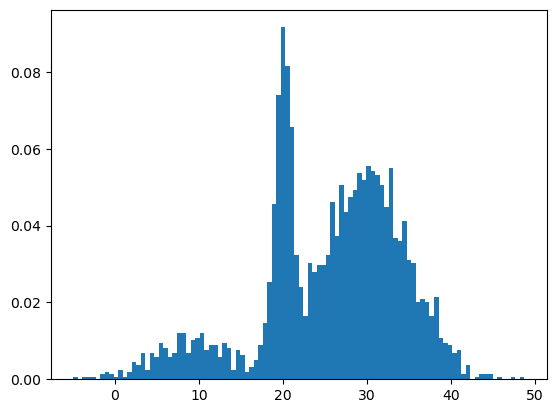

In [3]:
plt.hist(data, bins=100, density=True);

In [4]:
N=np.arange(1,10)
Models=[GaussianMixture(Ns).fit(data) for Ns in N]
AIC=[m.aic(data) for m in Models]

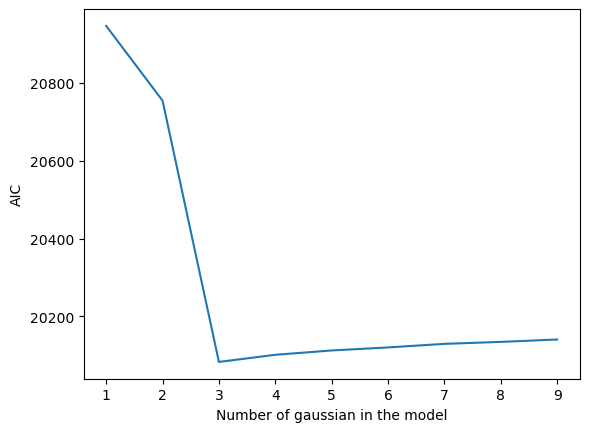

In [5]:
plt.plot(N,AIC)
plt.xlabel('Number of gaussian in the model')
plt.ylabel('AIC');

In [6]:
N[np.argmin(AIC)]
print("The model profered is with "+str(N[np.argmin(AIC)])+" gaussians")

The model profered is with 3 gaussians


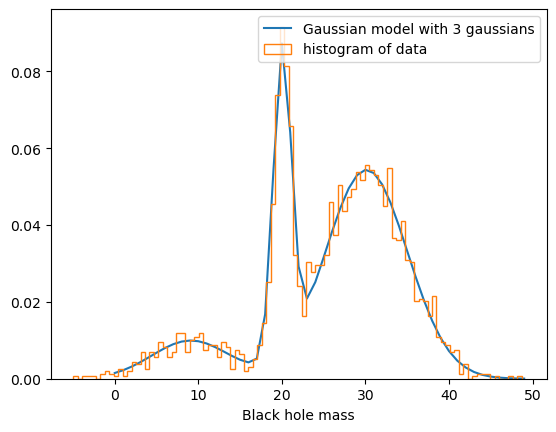

In [7]:
x=np.arange(0,50)
Best_model=Models[np.argmin(AIC)]
logprob=Best_model.score_samples(x.reshape(-1,1))
pdf=np.exp(logprob)

plt.plot(x, pdf, label='Gaussian model with 3 gaussians')
plt.xlabel('Black hole mass')
plt.hist(data, bins=100, density=True, histtype='step', label='histogram of data')
plt.legend();

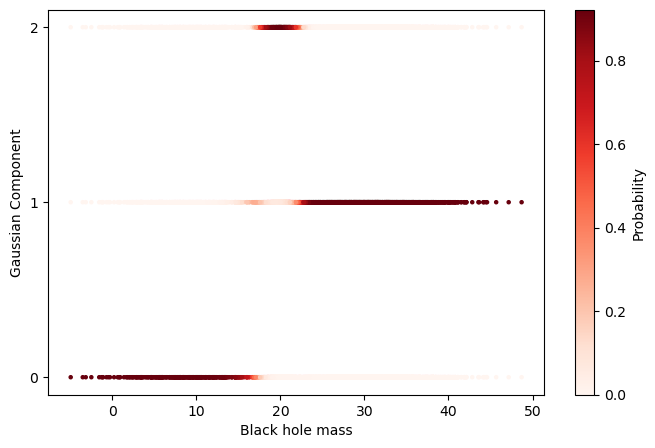

In [8]:
#see what data correspond to what mode ("formation channel").

probs = Best_model.predict_proba(data)

plt.figure(figsize=(8, 5))

for k in range(Best_model.n_components):
    plt.scatter(data, [k]*len(data), c=probs[:, k], cmap='Reds', s=5)
    
plt.xlabel('Black hole mass')
plt.ylabel("Gaussian Component")
plt.yticks(range(Best_model.n_components))
plt.colorbar(label="Probability")
plt.show()
